# Enviroment Setup

In [1]:
!pip install prophet

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = 'YOUR_PATH'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/PROPHET'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

# Model Definition - Prophet

In [5]:
def run_prophet_prediction(df, dataset_name, dataset_code, dataset_number, test_days=90):
    """
    Train Prophet on a single dataset and return metrics + predictions.
    Prophet uses its own feature engineering (trend, seasonality, holidays).
    Additional regressors: weather data.
    """
    print(f"\n{'='*100}")
    print(f"PROPHET PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # column renaming
    prophet_df = df[['date', 'total_tonnes']].copy()
    prophet_df.columns = ['ds', 'y']

    # additional data (weather)
    regressors = []
    for col in ['tavg', 'prcp', 'wspd']:
        if col in df.columns:
            prophet_df[col] = df[col].values
            regressors.append(col)


    # test / train split
    split_idx = len(prophet_df) - test_days
    train = prophet_df.iloc[:split_idx].copy()
    test = prophet_df.iloc[split_idx:].copy()

    print(f"Train: {len(train)} days ({train['ds'].min().date()} → {train['ds'].max().date()})")
    print(f"Test:  {len(test)} days ({test['ds'].min().date()} → {test['ds'].max().date()})")
    print(f"Additional regressors: {regressors}")


    # model fit
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05
    )

    for reg in regressors:
        model.add_regressor(reg)

    model.fit(train)
    print("Model trained.")


    # prediction - no negatives
    future = test[['ds'] + regressors].copy()
    forecast = model.predict(future)

    y_true = test['y'].values
    y_pred = forecast['yhat'].values

    y_pred = np.clip(y_pred, 0, None)


    # metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    nonzero_mask = y_true > 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        mape = float('nan')

    print(f"\n--- RESULTS ---")
    print(f"MAE:  {mae:.2f} tonnes")
    print(f"RMSE: {rmse:.2f} tonnes")
    print(f"MAPE: {mape:.2f}%")


    # --- Plot 5X1: Actual vs Predicted (test period) - Prophet ---
    fig, ax = plt.subplots(figsize=(16, 6))

    train_context = train.iloc[-30:]
    ax.plot(train_context['ds'], train_context['y'], color='steelblue',
            linewidth=1, label='Training Data (last 30 days)')

    ax.plot(test['ds'], y_true, color='steelblue',
            linewidth=1.5, label='Actual (Test)')

    ax.plot(test['ds'], y_pred, color='red',
            linewidth=1.5, linestyle='--', label='Prophet Forecast')

    # confidence interval
    ax.fill_between(test['ds'],
                     forecast['yhat_lower'].clip(lower=0),
                     forecast['yhat_upper'],
                     alpha=0.15, color='red', label='95% Confidence')

    ax.axvline(x=test['ds'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

    ax.set_title(f'Prophet Forecast vs Actual — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95,
            f'MAE: {mae:.2f}t\nRMSE: {rmse:.2f}t\nMAPE: {mape:.1f}%',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'5{dataset_number}1_prophet_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 5X2: Zoom on first 30 days of test - Prophet ---
    fig, ax = plt.subplots(figsize=(14, 5))

    zoom_days = min(30, test_days)
    ax.plot(test['ds'].iloc[:zoom_days], y_true[:zoom_days],
            color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')

    ax.plot(test['ds'].iloc[:zoom_days], y_pred[:zoom_days],
            color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='Prophet')

    ax.fill_between(test['ds'].iloc[:zoom_days],
                     forecast['yhat_lower'].iloc[:zoom_days].clip(lower=0),
                     forecast['yhat_upper'].iloc[:zoom_days],
                     alpha=0.15, color='red')

    ax.set_title(f'Prophet Forecast (First {zoom_days} Days) — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'5{dataset_number}2_prophet_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 5X3: Prophet components (trend + seasonality) ---
    fig = model.plot_components(forecast)
    plt.suptitle(f'Prophet Components — {dataset_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'5{dataset_number}3_prophet_components_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    return {
        'dataset': dataset_name,
        'model': 'Prophet',
        'mae': round(mae, 2),
        'rmse': round(rmse, 2),
        'mape': round(mape, 2),
        'test_days': test_days
    }

# Model Prediction -  Prophet

In [6]:
all_results = []

for idx, (name, config) in enumerate(DATASETS.items(), 1):
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_prophet_prediction(
            df=df,
            dataset_name=config['label'],
            dataset_code=config['code'],
            dataset_number=idx,
            test_days=90
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

Output hidden; open in https://colab.research.google.com to view.

# Prediction Summary

In [7]:
print("\n" + "=" * 100)
print("PROPHET RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'MAPE (%)':>9s}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['mape']:>8.2f}%")

print("-" * 65)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['mape'].mean():>8.2f}%")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'prophet_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/prophet_results.csv")


PROPHET RESULTS SUMMARY — ALL DATASETS

Dataset                        |  MAE (t) |  RMSE (t) |  MAPE (%)
-----------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     7.55 |      9.67 |    44.17%
Dehiwala MC (Sri Lanka)        |    34.69 |     43.01 |    52.67%
Homagama PS (Sri Lanka)        |    11.89 |     15.84 |    36.25%
Moratuwa MC (Sri Lanka)        |    24.57 |     29.40 |    34.69%
Austin TX (USA)                |   202.96 |    372.13 |    43.84%
Ballarat (Australia)           |    16.99 |     23.26 |    76.13%
-----------------------------------------------------------------
AVERAGE                        |    49.77 |     82.22 |    47.96%

Results saved to: /content/drive/MyDrive/DP/05_prediction_results/prophet_results.csv


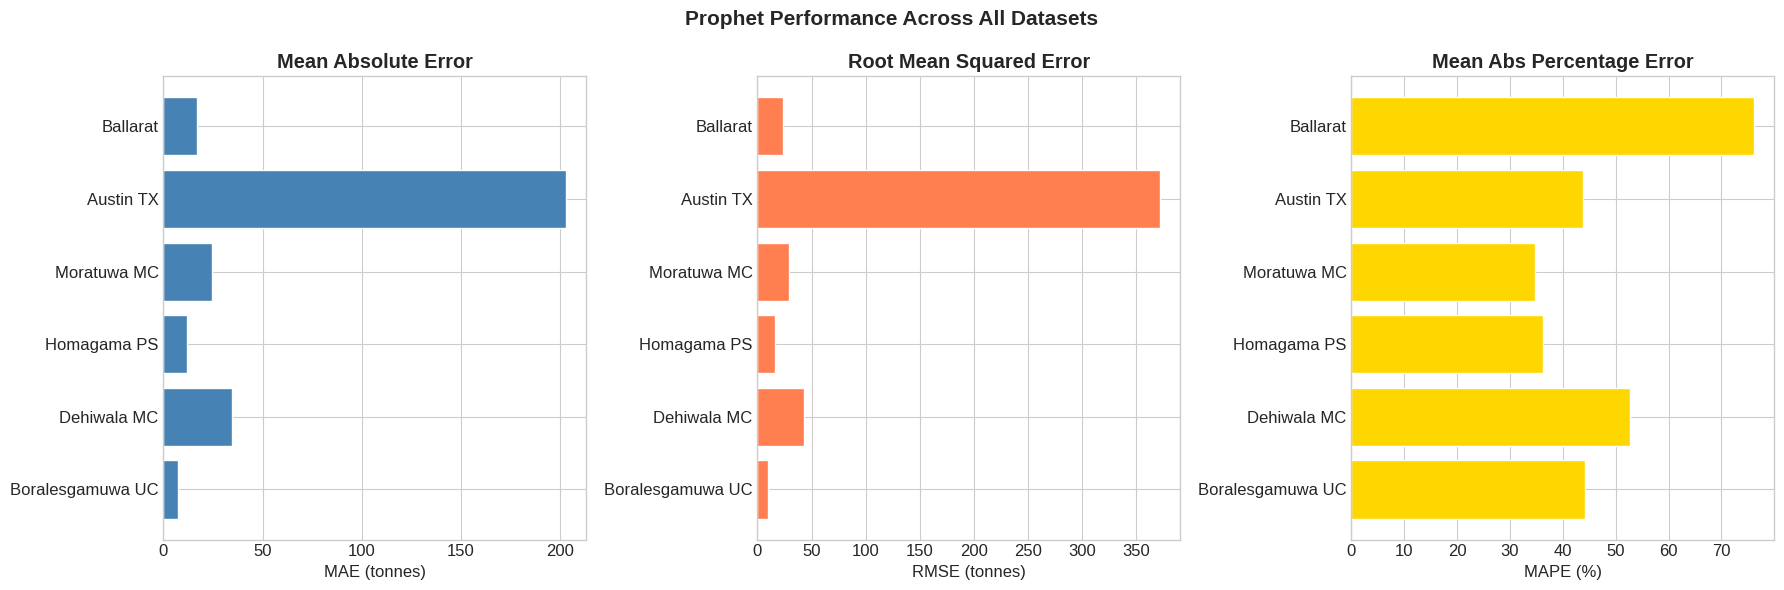

In [8]:
# --- Plot 501: Prophet Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

axes[2].barh(short_names, results_df['mape'], color='gold', edgecolor='white')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_title('Mean Abs Percentage Error', fontweight='bold')

plt.suptitle('Prophet Performance Across All Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '501_prophet_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()